# Chapter 6 — Ensemble Learning and Random Forests

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import make_moons, load_iris, fetch_openml
from sklearn.ensemble import (VotingClassifier, BaggingClassifier,
                               RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier, GradientBoostingRegressor,
                               RandomForestRegressor, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Voting Classifiers

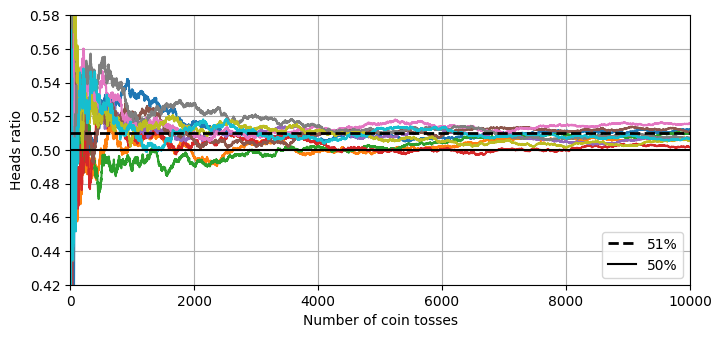

In [2]:
# extra code – this cell generates Figure 6–3

import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
rng = np.random.default_rng(seed=42)
coin_tosses = (rng.random((10000, 10)) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()

plt.show()

In [3]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("svc", SVC(random_state=42)),
    ],
)

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [ ]:
for name, clf in voting_clf.named_estimators_.items():
    y_pred = clf.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.2f}")

lr accuracy: 0.86
rf accuracy: 0.90
svc accuracy: 0.90


In [5]:
voting_clf.predict(X_test[:1])

array([1])

In [6]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [7]:
voting_clf.score(X_test, y_test)

0.912

## Distinsión entre hard voting y soft voting

Hard voting se basa en la mayoría de votos de los clasificadores individuales, mientras que soft voting promedia las probabilidades predichas por cada clasificador y elige la clase con la mayor probabilidad promedio.

Por otro lado soft voting suele ser más efectivo que hard voting, especialmente cuando los clasificadores individuales son bien calibrados y producen probabilidades confiables. Esto se debe a que soft voting tiene en cuenta la confianza de cada clasificador en sus predicciones, lo que puede mejorar la precisión del modelo final.


In [8]:
voting_clf.voting = "soft"
voting_clf.set_params(voting="soft", svc__probability=True)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

In [9]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Definimos los modelos base
lr_clf = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
svc_clf = SVC(random_state=42) # Nota: Aquí no necesitas probability=True si usas Calibrated

# 2. Calibramos los que lo necesiten (SVC y RF suelen mejorar mucho)
# CalibratedClassifierCV entrena el modelo internamente usando validación cruzada
calibrated_svc = CalibratedClassifierCV(svc_clf, cv=5)
calibrated_rf = CalibratedClassifierCV(rf_clf, cv=5)
calibrated_lr = CalibratedClassifierCV(lr_clf, cv=5)  # Aunque LR suele estar bien calibrado, lo incluimos para comparar

# 3. Metemos los modelos (calibrados y no calibrados) al VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ("lr", calibrated_lr),           # LogisticRegression ya suele estar bien calibrada
        ("rf", calibrated_rf),    # RF calibrado
        ("svc", calibrated_svc),  # SVC calibrado
    ],
)

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [10]:
for name, clf in voting_clf.named_estimators_.items():
    y_pred = clf.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.4f}")

lr accuracy: 0.8560
rf accuracy: 0.9120
svc accuracy: 0.9040


In [11]:
voting_clf.predict(X_test[:1])

array([0])

In [12]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([0]), array([1]), array([0])]

In [13]:
voting_clf.score(X_test, y_test)

0.92

In [14]:
voting_clf.named_estimators_

{'lr': CalibratedClassifierCV(cv=5, estimator=LogisticRegression(random_state=42)),
 'rf': CalibratedClassifierCV(cv=5, estimator=RandomForestClassifier(random_state=42)),
 'svc': CalibratedClassifierCV(cv=5, estimator=SVC(random_state=42))}

In [15]:
voting_clf.voting = "soft"
voting_clf.set_params(voting="soft", svc__estimator__probability=True)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.912

# Bagging and Pasting
## Bagging and Pasting in Scikit-Learn

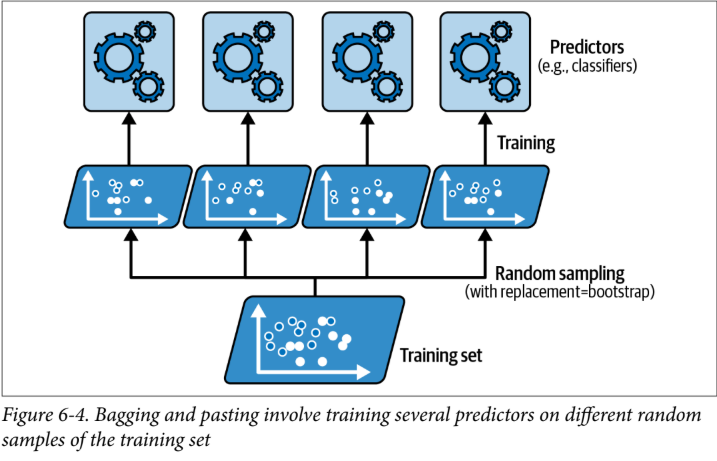

Esta tecnica implica:

1. **Bootstrap Sampling**: Se generan múltiples conjuntos de datos de entrenamiento a partir del conjunto de datos original mediante muestreo con reemplazo (bootstrap sampling). Esto significa que algunos ejemplos pueden aparecer varias veces en un conjunto de entrenamiento, mientras que otros pueden no aparecer en absoluto.

2. **Entrenamiento de Modelos**: Se entrena un modelo independiente en cada uno de los conjuntos de entrenamiento generados. Estos modelos pueden ser del mismo tipo (por ejemplo, todos árboles de decisión) o de tipos diferentes.

3. **Agregación de Predicciones**: Para hacer una predicción final, se agregan las predicciones de todos los modelos individuales. En problemas de clasificación, esto generalmente se hace mediante votación (hard voting o soft voting), mientras que en problemas de regresión se promedian las predicciones.

Pasting es similar a bagging, pero sin reemplazo. En pasting, cada modelo se entrena con un subconjunto diferente del conjunto de datos original, sin permitir que los mismos ejemplos se repitan en diferentes conjuntos de entrenamiento. Esto puede ser útil para reducir la varianza del modelo, aunque generalmente no es tan efectivo como el bagging para mejorar la precisión.

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)


,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


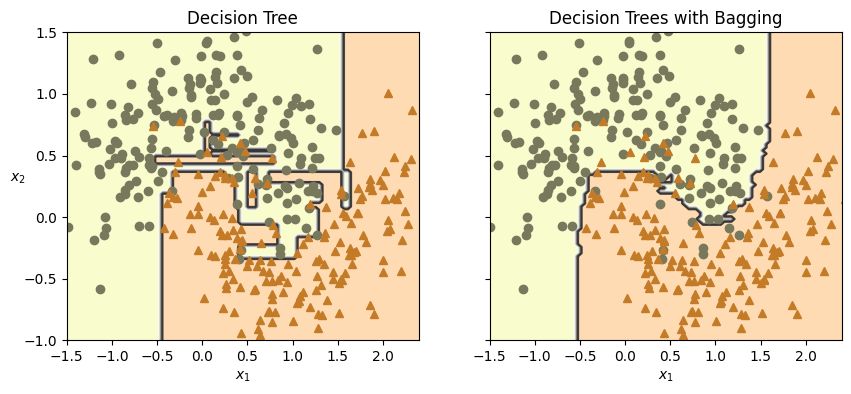

In [17]:
# extra code – this cell generates Figure 6–5

def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Trees with Bagging")
plt.ylabel("")

plt.show()

## Out-of-Bag Evaluation

El **OOB Evaluation** es una técnica exclusiva de los modelos basados en Bagging que permite evaluar el modelo utilizando los datos sobrantes del proceso de muestreo.

* **La Regla 63/37:** En promedio, cada predictor entrena con el 63% de las instancias. El 37% restante (Out-of-Bag) actúa como un conjunto de prueba natural.
* **Sin desperdicio de datos:** Permite entrenar con todo el dataset y aun así tener una validación confiable sin necesidad de un `X_val` separado.
* **Implementación en Scikit-Learn:** * Se activa con `oob_score=True`.
    * El resultado se consulta en el atributo `oob_score_`.
* **Interpretación:** Si tu `oob_score_` es 0.89, es muy probable que tu precisión en el conjunto de prueba real sea muy cercana a 0.89.

In [18]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [19]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

In [20]:
bag_clf.oob_decision_function_[:3] # probas for the first 3 instances

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

## Random Forests

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

Los bosques por defecto introduce algo de aleatoriedad en selección de features, que es $\sqrt{d}$, donde $d$ es el número total de características. Esto ayuda a reducir la correlación entre los árboles individuales, lo que a su vez mejora la precisión del modelo final.

In [22]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

## Extra-Trees

1. **Umbrales Aleatorios**: A diferencia de Random Forest (RF), que busca el umbral óptimo (split) para cada característica, Extra-Trees elige umbrales **al azar** y se queda con el mejor de esos resultados aleatorios[cite: 1].
2. **Sin Bootstrapping**: Por defecto, utiliza el dataset completo (`bootstrap=False`), lo que reduce el sesgo que introduce el muestreo con reemplazo[cite: 1].
3. **Trade-off de Error**: 
   - **↑ Sesgo (Bias)**: Al no optimizar el umbral, el error sistemático sube ligeramente.
   - **↓ Varianza (Variance)**: La aleatoriedad extrema suaviza el sobreajuste (*overfitting*).
4. **Eficiencia**: Es mucho más rápido de entrenar porque elimina el costo computacional de buscar el "umbral perfecto" en cada nodo[cite: 1].

In [23]:
from sklearn.ensemble import ExtraTreesClassifier

extra_clf = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16,
                                 bootstrap=False, random_state=42, n_jobs=-1)

extra_clf.fit(X_train, y_train)
y_pred_extra = extra_clf.predict(X_test)
accuracy_score(y_test, y_pred_extra)

0.912

## Feature Importance

In [24]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in sorted(zip(rnd_clf.feature_importances_, iris.feature_names), reverse=True):
    print(f"{name}: {score:.4f}")


petal length (cm): 0.4410
petal width (cm): 0.4234
sepal length (cm): 0.1125
sepal width (cm): 0.0231


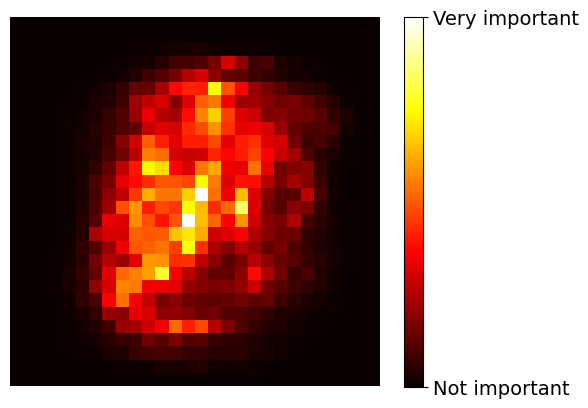

In [25]:
# extra code – this cell generates Figure 6–6

from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")

plt.show()

## Boosting
### AdaBoost

Primero hace un arbol base y luego se enfoca en los errores que cometió ese arbol, asignando más peso a las instancias mal clasificadas. Luego, se entrena un nuevo árbol que intenta corregir esos errores, y así sucesivamente. Al final, se combinan las predicciones de todos los árboles, dando más peso a aquellos que tuvieron un mejor desempeño.

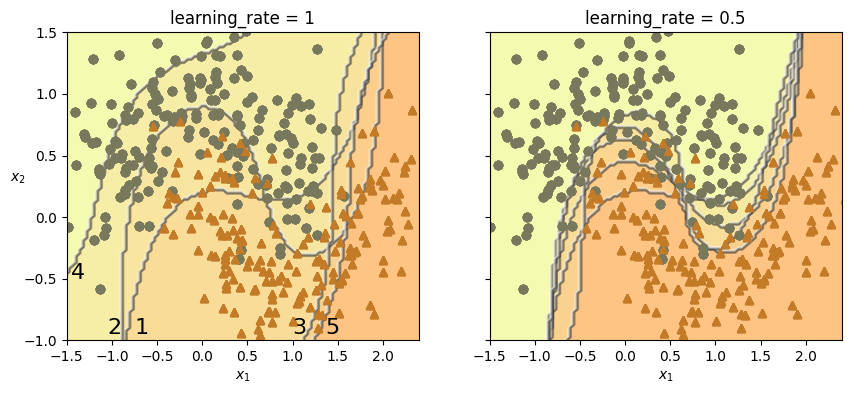

In [26]:
# extra code – this cell generates Figure 6–8

m = len(X_train)  # number of instances

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
for subplot, learning_rate in ((0, 1), (1, 0.5)):
    sample_weights = np.ones(m) / m
    plt.sca(axes[subplot])
    for i in range(5):
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()  # equation 7-1
        alpha = learning_rate * np.log((1 - r) / r)  # equation 7-2
        sample_weights[y_pred != y_train] *= np.exp(alpha)  # equation 7-3
        sample_weights /= sample_weights.sum()  # normalization step

        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0, -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5, "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")

plt.show()

AdaBoost entrena predictores de forma secuencial, donde cada nuevo modelo se enfoca en corregir los errores de los anteriores mediante la actualización de pesos de las instancias.

---

#### 1️⃣ Tasa de error ponderada del predictor ($r_j$)
Para el $j$-ésimo predictor, se calcula su tasa de error ponderada sobre el conjunto de entrenamiento:
$$r_j = \frac{\sum_{i=1, \hat{y}_j^{(i)} \neq y^{(i)}}^m w^{(i)}}{\sum_{i=1}^m w^{(i)}}$$
*Donde $\hat{y}_j^{(i)}$ es la predicción del predictor para la instancia $i$.*

#### 2️⃣ Peso del predictor ($\alpha_j$)
Calcula la importancia o "poder de voto" del modelo en el ensamble. A mayor precisión, mayor peso:
$$\alpha_j = \eta \log \frac{1 - r_j}{r_j}$$
*   **$\eta$**: Tasa de aprendizaje (hiperparámetro, por defecto 1).
*   Si $r_j$ es pequeño (buen modelo), $\alpha_j$ es alto y positivo.
*   Si $r_j = 0.5$ (azar), $\alpha_j$ es cero.

#### 3️⃣ Regla de actualización de pesos ($w^{(i)}$)
Se aumentan los pesos de las instancias mal clasificadas para que el siguiente modelo les preste más atención:
$$w^{(i)} \leftarrow \begin{cases} w^{(i)} & \text{si } \hat{y}_j^{(i)} = y^{(i)} \\ w^{(i)} \exp(\alpha_j) & \text{si } \hat{y}_j^{(i)} \neq y^{(i)} \end{cases}$$
*Tras la actualización, los pesos se normalizan para que su suma sea igual a 1[cite: 1].*

#### 4️⃣ Predicción final del ensamble
La clase predicha es la que obtiene la mayoría de los votos ponderados de todos los predictores ($N$):
$$\hat{y}(x) = \text{argmax}_k \sum_{j=1, \hat{y}_j(x) = k}^N \alpha_j$$

In [27]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,30
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


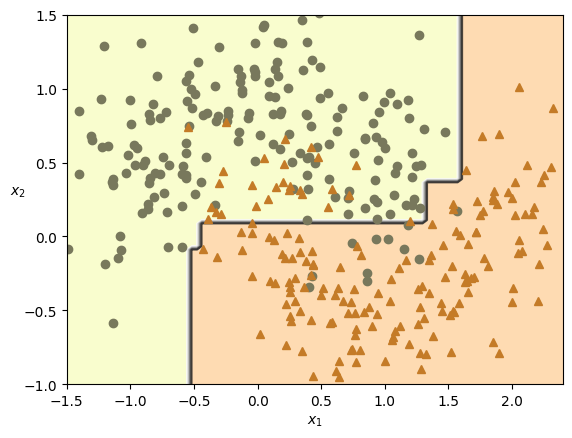

In [28]:
plot_decision_boundary(ada_clf, X_train, y_train)

## Gradient Boosting

In [29]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
m = 100 # number of instances
rng = np.random.default_rng(seed=42)
X = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)
y = 3 * X[:, 0] ** 2 + noise # y = 3x2 + Gaussian noise
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X, y2)
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X, y3)

X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.57356534, 0.0405142 , 0.66914249])

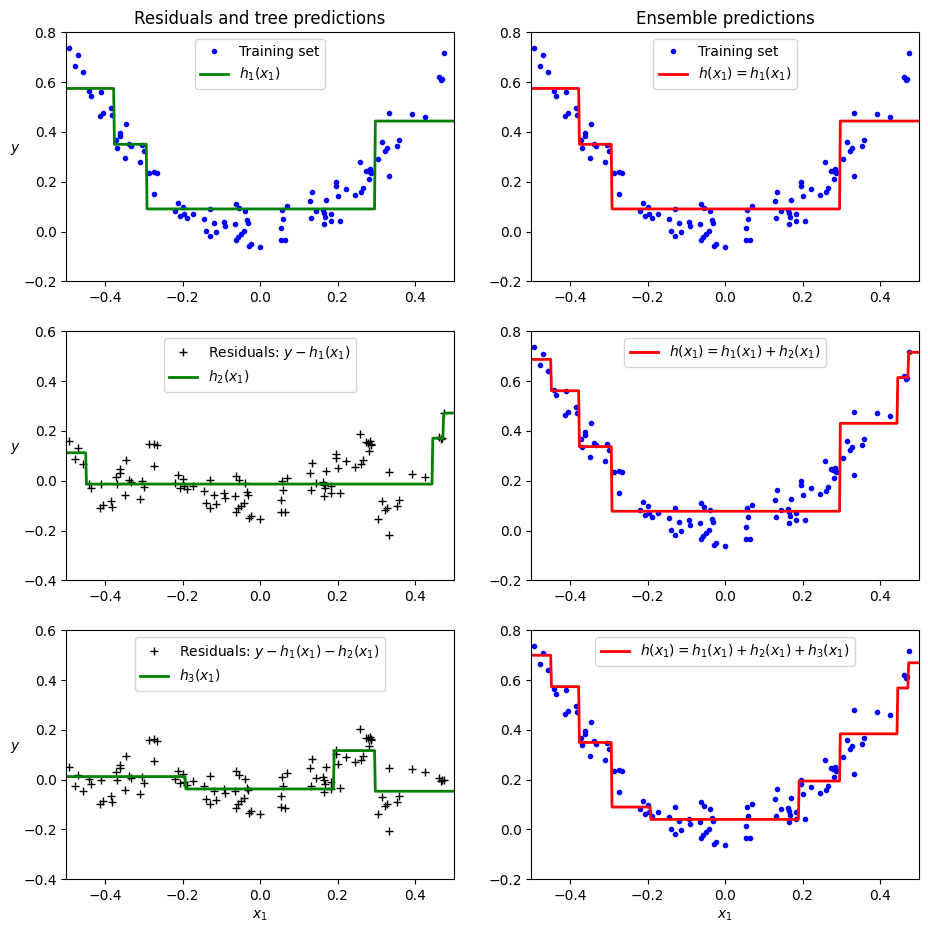

In [31]:
# extra code – this cell generates Figure 6–9

def plot_predictions(regressors, X, y, axes, style,
                     label=None, data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1))
                 for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

plt.figure(figsize=(11, 11))

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="g-",
                 label="$h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$  ", rotation=0)
plt.title("Residuals and tree predictions")

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.title("Ensemble predictions")

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_2(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1)$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.2, 0.8],
                  style="r-", label="$h(x_1) = h_1(x_1) + h_2(x_1)$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_3(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1) - h_2(x_1)$")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y,
                 axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$")

plt.show()

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                 learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

,loss,'squared_error'
,learning_rate,1.0
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [33]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [34]:
gbrt_best.n_estimators_

53

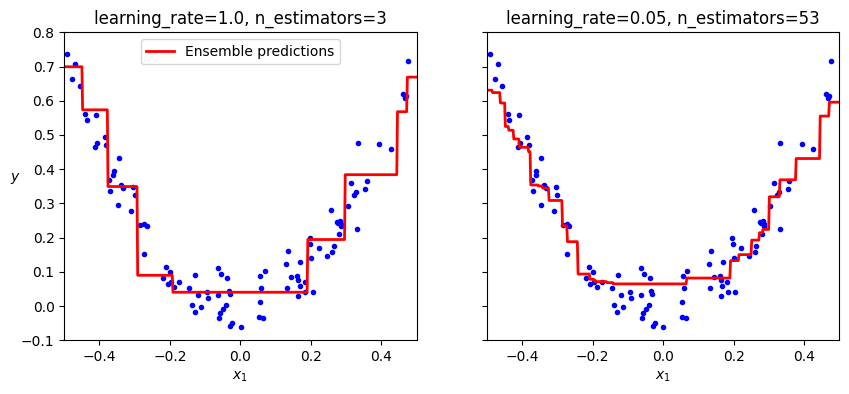

In [35]:
# extra code – this cell generates Figure 6–10

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-",
                 label="Ensemble predictions")
plt.title(f"learning_rate={gbrt.learning_rate}, "
          f"n_estimators={gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate={gbrt_best.learning_rate}, "
          f"n_estimators={gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")

plt.show()

## Histogram-Based Gradient Boosting

Este esta basado en performance para datasets enormes, gracias a la implementación de bins para las características numéricas, lo que reduce significativamente el tiempo de entrenamiento sin sacrificar la precisión.

La complejidad algoritmica del GradientBoosting original es de:
$$O(K \cdot N \cdot d \cdot \log(N))$$
Donde:
* $K$: Número de árboles.
* $N$: Número de instancias.
* $d$: Número de características.

En contraste, el Histogram-Based Gradient Boosting reduce esta complejidad a:

$$O(K \cdot N \cdot d)$$

https://ydf.readthedocs.io/en/stable/

In [36]:
# extra code – at least not in this chapter, it's presented in chapter 2

from pathlib import Path
import tarfile
import urllib.request

import pandas as pd
from sklearn.model_selection import train_test_split

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis=1)

C:\Users\sergi\AppData\Local\Temp\ipykernel_12852\1655387529.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [37]:
from sklearn.pipeline import make_pipeline 
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
    remainder="passthrough",
    force_int_remainder_cols=False),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)


hgb_reg.fit(housing, housing_labels)

c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('columntransformer', ...), ('histgradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
# extra code – evaluate the RMSE stats for the hgb_reg model

from sklearn.model_selection import cross_val_score

hgb_rmses = -cross_val_score(hgb_reg, housing, housing_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(hgb_rmses).describe()

c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and 

count       10.000000
mean     47613.307194
std       1295.422509
min      44963.213061
25%      47001.233485
50%      48000.963564
75%      48488.093243
max      49176.368465
dtype: float64

In [40]:
housing_labels.describe()

count     16512.000000
mean     206111.152980
std      114790.075691
min       14999.000000
25%      119400.000000
50%      179200.000000
75%      263800.000000
max      500001.000000
Name: median_house_value, dtype: float64

## Stacking

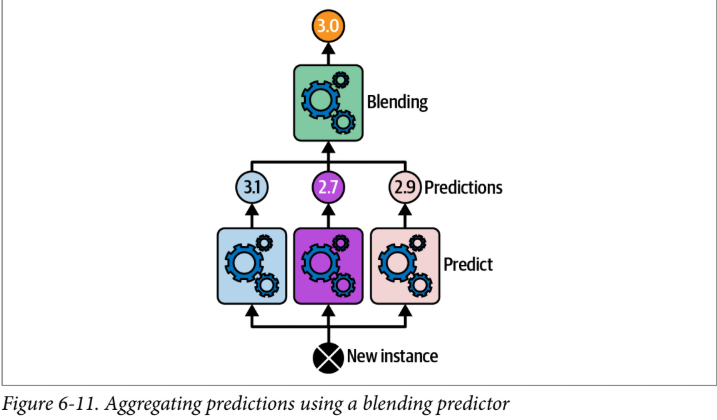
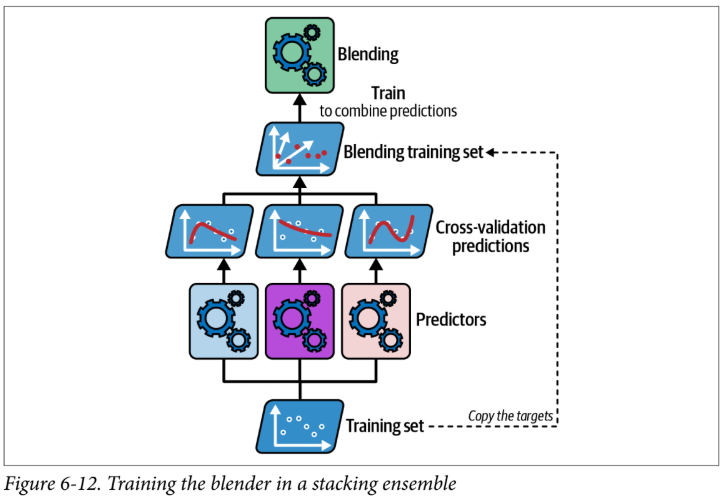

In [41]:
from sklearn.ensemble import StackingClassifier
stacking_clf = StackingClassifier(
    estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5 # number of cross-validation folds
)
stacking_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,RandomForestC...ndom_state=43)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Tabla 6-1. Cuándo usar cada método de aprendizaje por ensamble

| Método de Ensamble                  | Cuándo usarlo                                                                 | Casos de uso típicos                                                      |
|-------------------------------------|-------------------------------------------------------------------------------|---------------------------------------------------------------------------|
| **Hard voting**                     | Dataset de clasificación balanceado con varios clasificadores fuertes y diversos. | Detección de spam, análisis de sentimiento, clasificación de enfermedades |
| **Soft voting**                     | Dataset de clasificación con modelos probabilísticos donde importa la confianza. | Diagnóstico médico, análisis de riesgo crediticio, detección de fake news |
| **Bagging**                         | Dataset estructurado o semi-estructurado con modelos de alta varianza y propensos a overfitting. | Modelado de riesgo financiero, recomendación en ecommerce                 |
| **Pasting**                         | Dataset estructurado/semi-estructurado donde se buscan modelos más independientes. | Segmentación de clientes, clasificación de proteínas                      |
| **Random forest**                   | Datasets estructurados de alta dimensión con posibles features ruidosos.      | Predicción de churn, análisis genético, detección de fraude               |
| **Extra-trees**                     | Datasets estructurados grandes con muchas features, donde la velocidad y la reducción de varianza son clave. | Detección de fraude en tiempo real, análisis de datos de sensores         |
| **AdaBoost**                        | Datasets pequeños/medianos, estructurados y poco ruidosos, con weak learners (ej. stumps), donde la interpretabilidad ayuda. | Scoring crediticio, detección de anomalías, mantenimiento predictivo      |
| **Gradient boosting**               | Datasets medianos a grandes donde se requiere alto poder predictivo, aunque implique más tuning. | Predicción de precios de viviendas, evaluación de riesgo, forecasting     |
| **Histogram-based gradient boosting (HGB)** | Datasets estructurados grandes donde la velocidad de entrenamiento y la escalabilidad son clave. | Predicción de CTR, algoritmos de ranking, pujas en tiempo real en publicidad |
| **Stacking**                        | Datasets complejos y de alta dimensión donde combinar modelos diversos maximiza la precisión. | Motores de recomendación, toma de decisiones en vehículos autónomos, competencias Kaggle |

